In [1]:
%matplotlib widget
# Boilerplate import code for all libraries
# Changes to the precision require re-loading the kernel and need to be done before any op uses them.
import sphWarpCore_config as swc
from typing import Any
swc.configure(precision="float32", dim=Any) # precision: float16|half|float32|single|float64|double

import sphWarpCore as sph
from sphWarpCore.type_config import *
print(get_type_config()) # confirms active settings

# Initialize warp at this point
import warp as wp; wp.init()

import os
import torch
if torch.cuda.is_available(): # set the TORCH_CUDA_ARCH_LIST environment variable to the compute capability of the GPU for faster compiles
    os.environ['TORCH_CUDA_ARCH_LIST'] = f'{torch.cuda.get_device_properties(0).major}.{torch.cuda.get_device_properties(0).minor}'

import warnings
from tqdm import TqdmExperimentalWarning
warnings.filterwarnings("ignore", category=TqdmExperimentalWarning)
from tqdm.autonotebook import tqdm

# final import blocks that are generic
import matplotlib.pyplot as plt
from torch.profiler import profile, record_function, ProfilerActivity
import numpy as np
import math
import shlex    
import subprocess
import shutil

# custom SPH libraries
from integrators.integration import *
from sphWarpCore import *

# This library
from compressibleSPH import *
from compressibleSPH.modules.timestep.compressible import computeTimestep

# The case utilities that contain all the case setup functions for the various test cases
from compressibleSPH.caseUtils import *

{'scalar_t': <class 'warp._src.types.float32'>, 'dim_t': typing.Any}
Warp 1.12.0 initialized:
   CUDA Toolkit 12.9, Driver 13.2
   Devices:
     "cpu"      : "x86_64"
     "cuda:0"   : "NVIDIA RTX PRO 500 Blackwell Generation Laptop GPU" (6 GiB, sm_120, mempool enabled)
   Kernel cache:
     /home/lu26029/.cache/warp/1.12.0


In [2]:
nx = 256
dim = 2
L = 2
n_h = 4

gamma = 5/3
rho0 = 1
nu_visc = 0.0005

extraData = {
    'nx': nx,
    'dim': dim,
    'L': L,
    'n_h': n_h,

    'gamma': gamma,
    'rho0': rho0,
    'nu_visc': nu_visc,
}

In [3]:
device = torch.device('cuda:0') if torch.cuda.is_available() else torch.device('cpu')
dtype = get_torch_precision()

dx = L / nx
band = 5

domain = buildDomainDescription(L + dx * (band) * 2, dim, True, device, dtype)
interiorDomain = buildDomainDescription(L, dim, False, device, dtype)
# domain.min = torch.zeros(dim, device=device, dtype=dtype)
# domain.max = torch.ones(dim, device=device, dtype=dtype) * 2 * np.pi

config, integrator = buildConfig(
    domain = domain,
    dim = dim,
    kernel = KernelFunctions.Wendland4,
    targetNeighbors = n_h_to_nH(4, dim),
    supportMode = SupportScheme.KernelMeanSymmetric,
    gradientMode = GradientScheme.Difference,
    laplacianMode = LaplacianScheme.Brookshaw,
    integrationScheme = IntegrationSchemeType.rungeKutta2,
    samplingScheme = SamplingScheme.regular,
    device = device,
    dtype = dtype,
    dt = None,
    adaptiveDt = True,
    cflFactor=0.3,
)
config.nx = nx

config.minDt = 1e-8
# config.dx = L / (nx * 2)

scheme = WeaklyCompressibleSPHScheme.deltaSPH
SimulationSystem, SimulationState, SimulationConfig, SimulationUpdate, fn, export_fn, import_fn = buildScheme(scheme)


schemeConfig = SimulationConfig()


schemeConfig.viscositySwitchParams.scheme = ViscositySwitch.NoneSwitch
schemeConfig.adaptiveSupportScheme = AdaptiveSupportScheme.Owen
schemeConfig.adaptiveSupportCorrections = False


In [4]:
# import warnings
# from skimage import measure
# import numpy as np

# def find_contour(f, minExtent, maxExtent, nGrid, level = 0):
#     contours = measure.find_contours(f.numpy(), level)
#     for ic in range(len(contours)):
#         contours[ic][:,0] = (contours[ic][:,0]) / (f.shape[0] - 1) * (maxExtent[0] - minExtent[0]).numpy() + minExtent[0].numpy()
#         contours[ic][:,1] = (contours[ic][:,1]) / (f.shape[1] - 1) * (maxExtent[1] - minExtent[1]).numpy() + minExtent[1].numpy()
#     return contours



# def sampleParticles(config, sdfs = [], minExtent = None, maxExtent = None, filter = True):
#     # print(config['particle'])
#     particlesA = sampleRegularParticles(config['particle']['nx'], config['domain'], config['particle']['targetNeighbors'], 0.0, 0, shortEdge = config.get('particle', {}).get('shortEdge', True))

#     mask = torch.ones_like(particlesA.masses, dtype = torch.bool)
#     if len(sdfs) > 0:
#         distances = particlesA.masses.new_ones(particlesA.masses.shape) * np.inf
#         mask = torch.zeros_like(particlesA.masses, dtype = torch.bool)

#         for sdf_func in sdfs:            
#             sdfDist, sdfNormal = sdf_func(particlesA.positions)
#             maskA = sdfDist < 0
#             mask = mask | maskA
#             distances = torch.min(distances, sdfDist)
#         if filter:
#             particlesA = ParticleSet(
#                 positions = particlesA.positions[mask],
#                 supports = particlesA.supports[mask],
#                 masses = particlesA.masses[mask],
#                 densities = particlesA.densities[mask]            
#             )
#     else:
#         mask = torch.ones_like(particlesA.masses, dtype = torch.bool)
#         distances = particlesA.masses.new_ones(particlesA.masses.shape) * np.inf
#     return particlesA, mask, distances


# def buildRegion(sdf, config, ngrid = 255, kind : str = 'zero', type : str = 'fluid', dirichletValues = {}, updateValues = {}, bufferValues = [], initialConditions = {}, minOrMax = 'min'):
#     if config['domain'].dim == 2:
#         Lx = config['domain'].max[0] - config['domain'].min[0]
#         Ly = config['domain'].max[1] - config['domain'].min[1]
#         if minOrMax == 'min':
#             minL = min(Lx, Ly)
#         else:
#             minL = max(Lx, Ly)
            
#         dL = minL / ngrid
#         nx = (Lx//dL).to(torch.int32).cpu().item()
#         ny = (Ly//dL).to(torch.int32).cpu().item()

#         # print(nx, ny, ngrid)

#         # x = torch.linspace(config['domain'].min[0]-Lx * 0.01, config['domain'].max[0] + Lx*0.01, nx, dtype = torch.float32)
#         # y = torch.linspace(config['domain'].min[1]-Ly * 0.01, config['domain'].max[1] + Ly*0.01, ny, dtype = torch.float32)
#         x = torch.linspace(config['domain'].min[0], config['domain'].max[0], nx, dtype = torch.float32)
#         y = torch.linspace(config['domain'].min[1], config['domain'].max[1], ny, dtype = torch.float32)
#         X, Y = torch.meshgrid(x, y, indexing = 'ij')
#         P = torch.stack([X,Y], dim=-1)
#         domain = config['domain']
#         points = P.reshape(-1,2).to(domain.min.device).to(domain.min.dtype)
    
#     return {
#         'sdf': sdf,
#         'type': type,
#         'dirichlet': dirichletValues,
#         'dirichletUpdate': updateValues, 
#         'bufferValues': bufferValues,
#         'kind': kind,
#         'initialConditions': initialConditions,
#         'particles': sampleParticles(config, [sdf])[0],
#         'contour': find_contour(sdf(points)[0].reshape(nx, ny).cpu(), domain.min.cpu(), domain.max.cpu(), ngrid, 0) if config['domain'].dim == 2 else None,        
#     }
    
# def filterRegion(region, regions):
#     particles = region['particles']
#     if region['type'] == 'boundary' or region['type'] == 'dirichlet' or region['type'] == 'inlet' or region['type'] == 'outlet':
#         return region
#     for region_ in regions:
#         if region_['type'] == 'boundary':
#             sdfValues, sdfNormals = region_['sdf'](particles.positions)
#             mask = sdfValues > 0
#             particles = ParticleSet(
#                 positions = particles.positions[mask],
#                 supports = particles.supports[mask],
#                 masses = particles.masses[mask],
#                 densities = particles.densities[mask]            
#             )
#             region['particles'] = particles
#     return region



# def getInitialValue(region, pos, quantity, default):
#     if quantity not in region['initialConditions']:
#         return default
#     if callable(region['initialConditions'][quantity]):
#         return region['initialConditions'][quantity](pos)
#     else:
#         temp = torch.zeros_like(default)
#         temp[:] = region['initialConditions'][quantity]
#         return temp

# from diffSPH.schemes.states.wcsph import WeaklyCompressibleState
# def initializeWeaklyCompressibleState(regions, config, verbose = True):
#     if 'fluid' not in config:
#         if verbose:
#             warnings.warn('No fluid configuration found. Using default values.')
#         config['fluid'] = {}
#     if 'c_s' not in config['fluid']:
#         if verbose:
#             warnings.warn('No speed of sound found. Using default value.')
#         config['fluid']['c_s'] = 10       
#     if 'rho0' not in config['fluid']:
#         if verbose:
#             warnings.warn('No reference density found. Using default value.')
#         config['fluid']['rho0'] = 1

#     rho0 = config.get('fluid',{}).get('rho0', 1)
#     c_s = config.get('fluid',{}).get('c_s', 1)
#     dim = config['domain'].dim
    
#     fluidParticles = []
#     for region in regions:
#         if region['type'] == 'fluid' or region['type'] == 'inlet':
#             fluidParticles.append(region)
#     if len(fluidParticles) == 0:
#         raise ValueError('No fluid particles found. Please check the regions.')

#     if 'particle' not in config:
#         if verbose:
#             warnings.warn('No particle configuration found.')
#         config['particle'] = {}

#     if 'support' not in config['particle']:
#         if verbose:
#             warnings.warn('Using default support configuration.')
#         config['particle']['support'] = fluidParticles[0]['particles'].supports.mean().item()
#     if 'dx' not in config['particle']:
#         if verbose:
#             warnings.warn('Using default dx configuration.')
#         config['particle']['dx'] = fluidParticles[0]['particles'].masses.pow(1/dim).mean().item()

#     device = fluidParticles[0]['particles'].positions.device
#     dtype = fluidParticles[0]['particles'].positions.dtype

#     positions = []
#     supports = []
#     masses = []
#     velocities = []
#     densities = []
#     pressures = []
#     soundspeeds = []
#     kinds = []
#     materials = []

#     particleRegions = []
#     for region in regions:
#         if region['type'] == 'fluid' or region['type'] == 'boundary':
#             particleRegions.append(region)
#             positions.append(region['particles'].positions)
#             supports.append(getInitialValue(region, region['particles'].positions, 'supports', region['particles'].supports))
#             masses.append(getInitialValue(region, region['particles'].positions, 'masses', region['particles'].masses))
#             velocities.append(getInitialValue(region, region['particles'].positions, 'velocities', torch.zeros_like(region['particles'].positions)))
#             densities.append(getInitialValue(region, region['particles'].positions, 'densities', torch.ones_like(region['particles'].masses) * config['fluid']['rho0']))
#             pressures.append(getInitialValue(region, region['particles'].positions, 'pressures', torch.zeros_like(region['particles'].masses)))
#             soundspeeds.append(getInitialValue(region, region['particles'].positions, 'soundspeeds', torch.ones_like(region['particles'].masses) * config['fluid']['c_s']))
#     fluidMaterials = 0
#     boundaryMaterials = 0
    
#     for region in particleRegions:
#         if region['type'] == 'fluid':
#             kinds.append(torch.zeros_like(region['particles'].masses, dtype = torch.int64))
#             materials.append(torch.ones_like(region['particles'].masses, dtype = torch.int64) * fluidMaterials)
#             fluidMaterials += 1
#         elif region['type'] == 'boundary':
#             kinds.append(torch.ones_like(region['particles'].masses, dtype = torch.int64))
#             materials.append(torch.ones_like(region['particles'].masses, dtype = torch.int64)* boundaryMaterials)
#             boundaryMaterials += 1
            
#     kinds = torch.cat(kinds, dim = 0)
#     materials = torch.cat(materials, dim = 0)
#     positions = torch.cat(positions, dim = 0)
#     UIDs = torch.arange(positions.shape[0], device = device, dtype = torch.int64)

#     supports = torch.cat(supports, dim = 0)
#     masses = torch.cat(masses, dim = 0)
#     velocities = torch.cat(velocities, dim = 0)
#     densities = torch.cat(densities, dim = 0)
#     pressures = torch.cat(pressures, dim = 0)
#     soundspeeds = torch.cat(soundspeeds, dim = 0)

#     particleState = WeaklyCompressibleState(
#         positions,
#         supports = supports,
#         masses = masses * config.get('fluid',{}).get('rho0', 1),
        
#         densities = densities,
#         velocities = velocities,
        
#         pressures = pressures,
#         soundspeeds = soundspeeds,
        
#         kinds = kinds,
#         materials = materials,
#         UIDs = UIDs,
        
#         UIDcounter = positions.shape[0],
#     )

#     return particleState, config



In [5]:

# domain = buildDomainDescription(l = L + dx * (band) * 2, dim = dim, periodic = True, device = device, dtype = dtype)
# interiorDomain = buildDomainDescription(l = L, dim = dim, periodic = False, device = device, dtype = dtype)

fluid_sdf = lambda x: sampleDomainSDF(x, domain, invert = True)
domain_sdf = lambda x: sampleDomainSDF(x, interiorDomain, invert = False)
obstacle_sdf = lambda points: sampleSDF(points, lambda x: getSDF('circle')['function'](x, torch.tensor(1/4).to(points.device)), invert = False)


In [6]:
regions = []

regions.append(buildRegion(config, schemeConfig, fluid_sdf, RegionType.Fluid, initialConditions = {}))
regions.append(buildRegion(config, schemeConfig, domain_sdf, RegionType.Boundary, initialConditions = {}))
regions.append(buildRegion(config, schemeConfig, obstacle_sdf, RegionType.Boundary, initialConditions = {}))

In [7]:


for region in regions:
    region = filterRegion(region, regions)


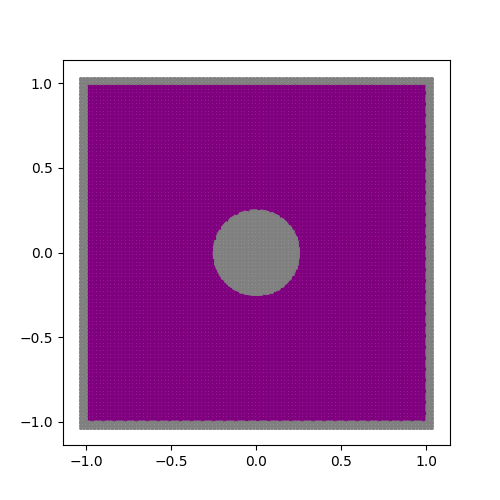

In [8]:



fig, axis = plt.subplots(1, 1, figsize=(5, 5), squeeze=False)
    
plotRegions(regions, axis[0,0], plotFluid = True, plotParticles = True)


In [9]:
# from compressibleSPH.systems import *








In [10]:
compressibleSystem = initializeWeaklyCompressibleSimulation(regions, config, schemeConfig, SimulationSystem, SimulationState, verbose = True)

In [75]:
nu_inviscid = alphaToNu(0.01, schemeConfig.fluid.fixedSoundSpeed, compressibleSystem.state.supports.mean().cpu().item(), config.dim)
alpha_effective = nuToAlpha(nu_visc, schemeConfig.fluid.fixedSoundSpeed, compressibleSystem.state.supports.mean().cpu().item(), config.dim)
print(f"nu_inviscid: {nu_inviscid}, alpha_effective: {alpha_effective}")

nu_inviscid: 0.0004058837890625, alpha_effective: 0.012318796992481203


In [76]:
k = 2
u_mag = 1
k_ = k

ktgv = k_ / 2
if k_ % 2 == 0:
    phaseShift_x = np.pi / 2# / k
    phaseShift_y = np.pi / 2# / k
else:
    phaseShift_x = 0
    phaseShift_y = 0

# compressibleSystem.state.velocities[:,0] =  u_mag * torch.cos(ktgv * np.pi * compressibleSystem.state.positions[:,0] + phaseShift_x) * torch.sin(ktgv * np.pi * compressibleSystem.state.positions[:,1] + phaseShift_y)
# compressibleSystem.state.velocities[:,1] = -u_mag * torch.sin(ktgv * np.pi * compressibleSystem.state.positions[:,0] + phaseShift_x) * torch.cos(ktgv * np.pi * compressibleSystem.state.positions[:,1] + phaseShift_y)

compressibleSystem.state.velocities[:,0] =  u_mag * torch.cos(ktgv * compressibleSystem.state.positions[:,0] + phaseShift_x) * torch.sin(ktgv *  compressibleSystem.state.positions[:,1] + phaseShift_y)
compressibleSystem.state.velocities[:,1] = -u_mag * torch.sin(ktgv * compressibleSystem.state.positions[:,0] + phaseShift_x) * torch.cos(ktgv * compressibleSystem.state.positions[:,1] + phaseShift_y)


In [77]:
ke0 = compressibleSystem.state.masses * torch.linalg.norm(compressibleSystem.state.velocities, dim=1)**2 * 0.5
m_total = compressibleSystem.state.masses.sum().cpu().item()
# kineticEnergy = np.array([ke.cpu().item() for ke in kes]).sum()

domainL = config.domain.max[0].cpu().item() - config.domain.min[0].cpu().item()
Ek0_theoretical = 0.25 * u_mag**2 * schemeConfig.fluid.restDensity * domainL**2
# print(f"Theoretical initial kinetic energy: {Ek0_theoretical:.6g}")
# print(f"Initial kinetic energy from simulation: {ke0.sum().cpu().item():.6g}")
print(f'Difference: {abs(Ek0_theoretical - ke0.sum().cpu().item()):.6g}')

Difference: 0.190993


Module sphWarpCore.radiusSearch.wp_compactHash e67fccd load on device 'cuda:0' took 6.45 ms  (cached)
Module sphWarpCore.operations_grid.wp_interpolate_grid bde6e7c load on device 'cuda:0' took 11.73 ms  (cached)
Module sphWarpCore.operations_grid.wp_interpolate_grid 2282a2d load on device 'cuda:0' took 9.06 ms  (cached)


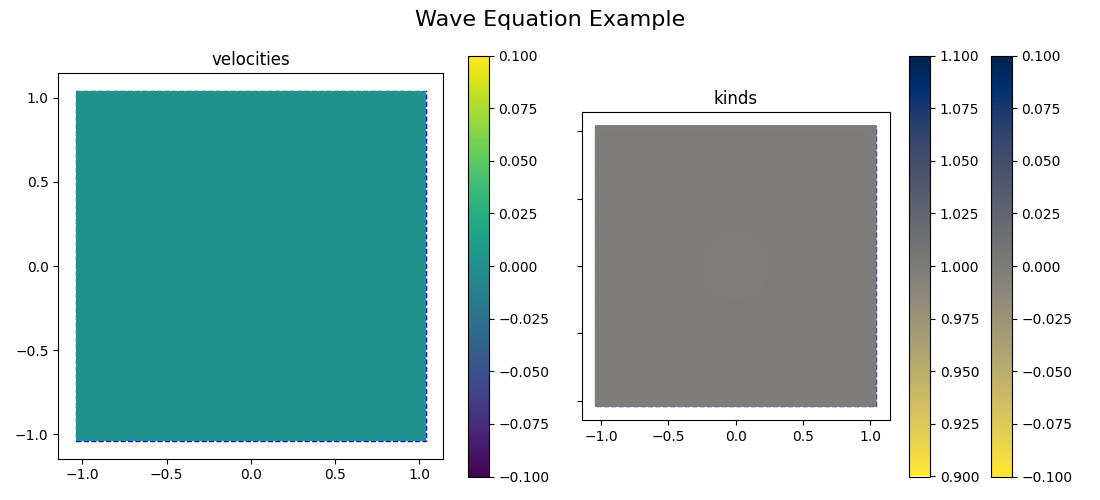

In [11]:
runningState = compressibleSystem.initializeNewState()

from warpPlot import visualize, PlottingOptions, PlotScaling, GridVisualization, UniformColorMap, Mapping, DivergingColorMap, VisualizeOptions
markerSize = 1
plotter = visualize(
    particleState = runningState.state,
    domain = config.domain,
    quantities = {
        "A": runningState.state.velocities,
        "B": runningState.state.kinds,
    },
    plotOptions = {
        "A": PlottingOptions(
            colorMap = UniformColorMap.viridis,
            markerSize = markerSize,
            midPoint = 0.0,
            quantityScaling = PlotScaling.Linear,
            mapping = Mapping.L2,
            plotTitle = "velocities",
            gridVisualization = GridVisualization(
                resolution = 128,
                streamLines = True
            ),
            boundaryVisualization = VisualizeOptions.Hide,
            # # vMin=1e-10,
            # stream
        ),
        "B": PlottingOptions(
            colorMap = UniformColorMap.cividis,
            flipColorMap=True,
            markerSize = markerSize,
            midPoint = 0.0,
            quantityScaling = PlotScaling.Linear,
            plotTitle = "kinds",
            mapping = Mapping.x,
            boundaryVisualization = VisualizeOptions.Visualize,
            # gridVisualization = GridVisualization(
            #     resolution = 512,
            # ),
        ),
    },
    figTitle = "Wave Equation Example",
    mosaic = 'AB',
    figsize= (11,5),
    backend='matplotlib',
    # backend='pyVista',
    # backendOptions = {
    #     # In notebooks, use trame for reliable live updates.
    #     'jupyter_backend': 'trame',
    # }
)

# if args.exportImages:
#     plotter.export(f'output/{folderName}/frame_00000.png', dpi = args.figureDpi)


# imagePath = f'{exportPath}/images'
# os.makedirs(imagePath, exist_ok = True)
# plotter.export(f'{imagePath}/frame_00000.png', dpi = 300)

In [9]:
runningState = compressibleSystem.initializeNewState()
from compressibleSPH.modules.timestep.weaklyCompressible import computeTimestep

config.dt = computeTimestep(
    system = compressibleSystem,
    config = config,
    compParams = schemeConfig,
    dt = 1e-4,
    systemUpdate = None,
)
print(config.dt)

tensor(0.0008, device='cuda:0')


In [10]:
from warpPlot import visualize, PlottingOptions, PlotScaling, GridVisualization, UniformColorMap, Mapping, DivergingColorMap
markerSize = 16
plotter = visualize(
    particleState = runningState.state,
    domain = config.domain,
    quantities = {
        "A": runningState.state.velocities,
        "B": runningState.state.densities,
    },
    plotOptions = {
        "A": PlottingOptions(
            colorMap = UniformColorMap.viridis,
            markerSize = markerSize,
            midPoint = 0.0,
            quantityScaling = PlotScaling.Linear,
            mapping = Mapping.L2Norm,
            plotTitle = "velocities",
            # gridVisualization = GridVisualization(
            #     resolution = 512,
            # ),
            # vMin=1e-10
        ),
        "B": PlottingOptions(
            colorMap = DivergingColorMap.RdBu,
            flipColorMap=True,
            markerSize = markerSize,
            midPoint = 1.0,
            quantityScaling = PlotScaling.Linear,
            plotTitle = "densities",
            # gridVisualization = GridVisualization(
            #     resolution = 512,
            # ),
        ),
    },
    figTitle = "Wave Equation Example",
    mosaic = 'AB',
    figsize= (11,5),
    backend='vispy',
    # backend='pyVista',
    # backendOptions = {
    #     # In notebooks, use trame for reliable live updates.
    #     'jupyter_backend': 'trame',
    # }
)


RFBOutputContext()

In [ ]:
runningState = compressibleSystem.initializeNewState()
ke = torch.sum(0.5 * runningState.state.densities * torch.sum(runningState.state.velocities**2, dim=1)) / torch.sum(runningState.state.densities)

schemeConfig.diffusionParams.inviscid = False
schemeConfig.diffusionParams.nu = 0.01

In [12]:

t_limit = 2.0
nSteps = int(t_limit / config.dt)

runningState = compressibleSystem.initializeNewState()

kes = []
priorStep = None
for i in (tq := tqdm(range(nSteps), leave = False)):
    begin = torch.cuda.Event(enable_timing=True)
    end = torch.cuda.Event(enable_timing=True)
    begin.record()
    result = integrator.function(
        state = runningState,
        f = fn,
        dt = config.dt,  
        config = config,
        schemeConfig = schemeConfig,
        verbose = False,
        priorStep = priorStep
    )
    kes.append(torch.sum(0.5 * result.state.state.masses * torch.sum(result.state.state.velocities**2, dim=1)))
    # print('max_vel:', torch.linalg.norm(result.state.state.velocities, dim = -1).max())
    end.record()
    torch.cuda.synchronize()
    priorStep = result.stages[-1]
    timing = begin.elapsed_time(end)

    runningState = result.state

    if i % 60 == 0 and i > 0:
        plotter.updateQuantities(
            {
                "A": runningState.state.velocities,
                "B": runningState.state.densities,
            },
            newParticleState = runningState.state,
        )
        
    maxVel = torch.linalg.norm(runningState.state.velocities, dim = -1).max()
    tq.set_description(f"Step {i+1}/{nSteps}, time: {(i+1)*config.dt:8.4g}/{t_limit:8.4g} | max vel: {maxVel:.3g} | iter time: {timing:.3f} ms")
    # t = {runningState.t:2f}, dt = {config.dt:.3g}, ptcls = {len(runningState.state.positions)}\nTotal Energy: {totalEnergy:.3g}, Kinetic Energy: {kineticEnergy:.3g}, Thermal Energy: {thermalEnergy:.3g}'
    # break
    if torch.any(torch.isnan(runningState.state.velocities)):
        print("NaN detected in velocities, stopping simulation.")
        break


ts = np.arange(len(kes)) * config.dt.cpu().item()
kineticEnergy = np.array([ke.cpu().item() for ke in kes])
E_k0 = kineticEnergy[0]

# Fit an effective viscosity from d/dt log(E_k) = -4 * (ktgv**2) * nu_eff
mask = (ts > 0) & (kineticEnergy > 0)
slope = np.polyfit(ts[mask], np.log(kineticEnergy[mask] / E_k0), 1)[0]
nu_eff = -slope / (4 * ktgv**2)

  0%|          | 0/2422 [00:00<?, ?it/s]

Module sphWarpCore.renorm.wp_covariance 58ede18 load on device 'cuda:0' took 5.57 ms  (cached)
Module sphWarpCore.operations.wp_gradient 2d3b13a load on device 'cuda:0' took 5.24 ms  (cached)
Module compressibleSPH.modules.deltaSPH.wp_densityDelta bff23b3 load on device 'cuda:0' took 5.25 ms  (cached)
Module compressibleSPH.modules.deltaSPH.wp_viscosityDelta 58bfbac load on device 'cuda:0' took 3.83 ms  (cached)
Module sphWarpCore.operations.wp_divergence 7313a53 load on device 'cuda:0' took 4.46 ms  (cached)
Module compressibleSPH.modules.pressure.wp_surfaceAware 984a4fa load on device 'cuda:0' took 3.66 ms  (cached)
Module sphWarpCore.operations.wp_density f0357bf load on device 'cuda:0' took 3.07 ms  (cached)
Module compressibleSPH.sample.wp_deltaShift 2c9a194 load on device 'cuda:0' took 5.61 ms  (cached)


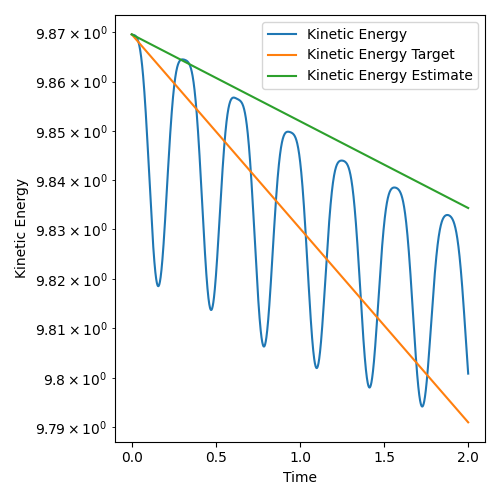

: 

In [ ]:
fig, axis = plt.subplots(1, 1, figsize=(5, 5), squeeze=False)

ts = np.arange(len(kes)) * config.dt.cpu().item()
kineticEnergy = np.array([ke.cpu().item() for ke in kes])

nu = schemeConfig.diffusionParams.viscidNu

Ek0_theoretical = 0.25 * u_mag**2 * schemeConfig.fluid.restDensity * domainL**2

# For u ~ exp(-2*nu*k_mode^2*t), kinetic energy decays as exp(-4*nu*k_mode^2*t).
E_kestimate = Ek0_theoretical * np.exp(-4 * ts * (ktgv**2) * nu_eff)
E_ktarget = Ek0_theoretical * np.exp(-4 * ts * (ktgv**2) * nu)

axis[0,0].plot(ts, kineticEnergy, label='Kinetic Energy')
axis[0,0].plot(ts, E_ktarget, label='Kinetic Energy Target')
axis[0,0].plot(ts, E_kestimate, label='Kinetic Energy Estimate')
axis[0,0].set_xlabel('Time')
axis[0,0].set_ylabel('Kinetic Energy')
axis[0,0].legend()

axis[0,0].set_yscale('log')

fig.tight_layout()

In [ ]:
# exportSimulationSystem(exportPath, f'finalState', scheme, runningState, exportAdjacency = False, stages = result.stages, exportStagesAdjacency = True, extraData = dict(**extraData, **{
#     'kineticEnergy': kineticEnergy,
#     'thermalEnergy': thermalEnergy,
#     'totalEnergy': totalEnergy,
#     'frame_num': i,
# }))

In [ ]:
# ffmpeg_cmd = "ffmpeg -y -loglevel error -hide_banner -framerate 50 -f image2 -pattern_type glob -i 'frame_*.png' -c:v libx264 -pix_fmt yuv420p -b:v 10M output.mp4"
# subprocess.run(shlex.split(ffmpeg_cmd), check=True, cwd = imagePath)
# ffmpeg_cmd = 'ffmpeg -y -loglevel error -hide_banner -i output.mp4  -vf "fps=50,scale=540:-1:flags=lanczos,palettegen" palette.png'
# subprocess.run(shlex.split(ffmpeg_cmd), check=True, cwd = imagePath)
# ffmpeg_cmd = 'ffmpeg -y -loglevel error -hide_banner -i output.mp4 -i palette.png -filter_complex "fps=25,scale=540:-1:flags=lanczos[x];[x][1:v]paletteuse" out.gif'
# subprocess.run(shlex.split(ffmpeg_cmd), check=True, cwd = imagePath)

# # now copy the output.mp4 and out.gif to the parent directory for easier access
# shutil.copy(f'{imagePath}/output.mp4', f'{exportPath}/output.mp4')
# shutil.copy(f'{imagePath}/out.gif', f'{exportPath}/out.gif');